In [83]:
# ============================================
# IMPORTING REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display charts inside notebook
%matplotlib inline

# Optional styling
sns.set_style("whitegrid")

In [51]:

# ============================================
# LOADING DATASET
# ============================================

df = pd.read_csv("sales_data.csv")

# Display first 5 rows
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2/3/2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,4/21/2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,9/21/2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,8/24/2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,3/24/2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [52]:
# ============================================
# BASIC INFORMATION ABOUT DATASET
# ============================================

# Number of rows and columns
print(df.shape)

# Column names
print(df.columns)

# Data types and null values
df.info()

(1000, 14)
Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 1

In [53]:
# ============================================
# STATISTICAL SUMMARY
# ============================================

df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [54]:
# ============================================
# CHECKING MISSING VALUES
# ============================================

df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [55]:
# ============================================
# CONVERTING DATE COLUMN
# ============================================

df['Sale_Date'] = pd.to_datetime(
    df['Sale_Date'],
    errors='coerce'
)

In [56]:
# ============================================
# REMOVING DUPLICATES
# ============================================

df = df.drop_duplicates()

In [57]:
# ============================================
# FILLING MISSING DISCOUNT VALUES
# ============================================

df['Discount'] = df['Discount'].fillna(0)

In [58]:
# ============================================
# CREATING PROFIT COLUMN
# ============================================

df['Profit'] = (
    (df['Unit_Price'] - df['Unit_Cost'])
    * df['Quantity_Sold']
)

In [ ]:
# ============================================
# CREATING PROFIT MARGIN COLUMN
# ============================================

df['Profit_Margin'] = (
    df['Profit'] / df['Sales_Amount']
) * 100

In [ ]:
# ============================================
# EXTRACTING DATE FEATURES
# ============================================

df['Year'] = df['Sale_Date'].dt.year
df['Month'] = df['Sale_Date'].dt.month
df['Month_Name'] = df['Sale_Date'].dt.month_name()

In [ ]:
# ============================================
# TOTAL SALES
# ============================================

total_sales = df['Sales_Amount'].sum()

print("Total Sales:", total_sales)

Total Sales: 5019265.2299999995


In [ ]:
# ============================================
# TOTAL PROFIT
# ============================================

total_profit = df['Profit'].sum()

print("Total Profit:", total_profit)

Total Profit: 6487847.07


In [ ]:
# ============================================
# AVERAGE SALES
# ============================================

average_sales = df['Sales_Amount'].mean()

print("Average Sales:", average_sales)

Average Sales: 5019.265229999999


In [ ]:
# ============================================
# SALES BY REGION
# ============================================

region_sales = df.groupby('Region')[
    'Sales_Amount'
].sum().sort_values(ascending=False)

print(region_sales)


Region
North    1369612.51
East     1259792.93
West     1235608.93
South    1154250.86
Name: Sales_Amount, dtype: float64


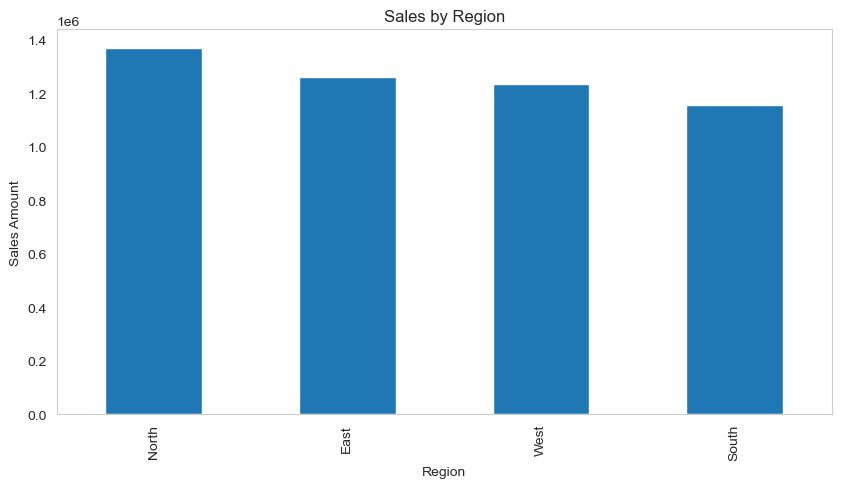

In [ ]:
# ============================================
# VISUALIZATION - REGION SALES
# ============================================

region_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales Amount")
plt.grid(False)
plt.savefig(
    "charts/region_sales.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [71]:
# ============================================
# TOP SALES REPRESENTATIVES
# ============================================

sales_rep = df.groupby('Sales_Rep')[
    'Sales_Amount'
].sum().sort_values(ascending=False)

print(sales_rep)

Sales_Rep
David      1141737.36
Bob        1080990.63
Eve         970183.99
Alice       965541.77
Charlie     860811.48
Name: Sales_Amount, dtype: float64


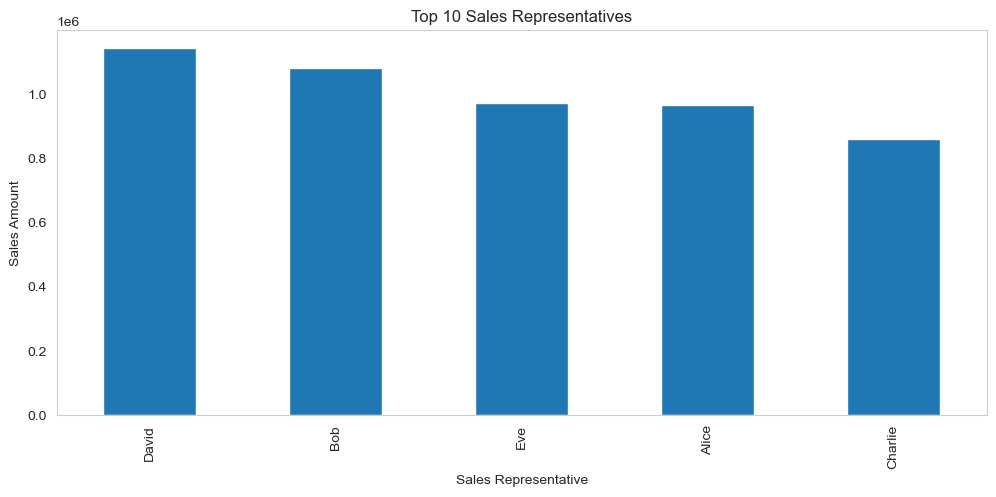

In [73]:
# ============================================
# VISUALIZATION - SALES REP PERFORMANCE
# ============================================

sales_rep.head(10).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Sales Representatives")
plt.xlabel("Sales Representative")
plt.ylabel("Sales Amount")
plt.grid(False)
plt.savefig(
    "charts/sales_rep_performance.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
# ============================================
# PRODUCT CATEGORY SALES
# ============================================

category_sales = df.groupby(
    'Product_Category'
)['Sales_Amount'].sum()

print(category_sales)


Product_Category
Clothing       1313474.36
Electronics    1243499.64
Food           1201773.54
Furniture      1260517.69
Name: Sales_Amount, dtype: float64


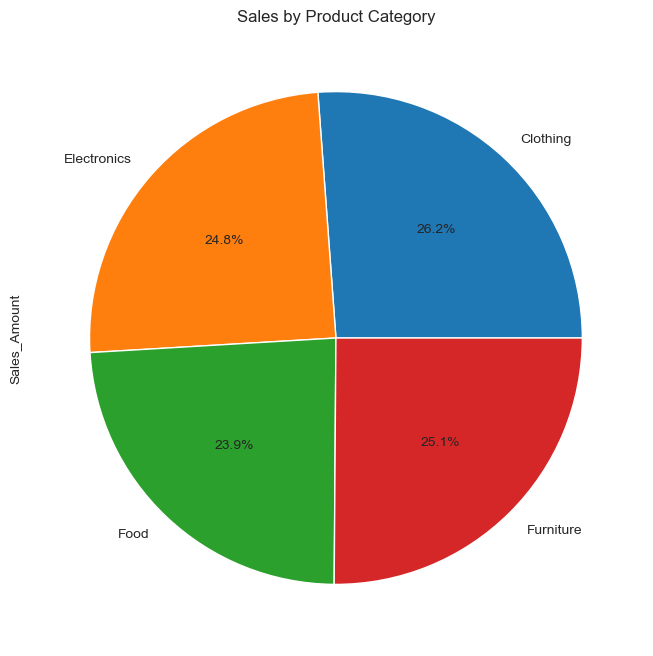

In [ ]:
# ============================================
# VISUALIZATION - PRODUCT CATEGORY SALES
# ============================================

category_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title("Sales by Product Category")
plt.savefig(
    "charts/sales_by_category.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
# ============================================
# MONTHLY SALES TREND
# ============================================

monthly_sales = df.groupby(
    'Month_Name'
)['Sales_Amount'].sum()

print(monthly_sales)

Month_Name
April        438992.61
August       443171.28
December     392643.58
February     368919.36
January      495420.37
July         374242.88
June         418458.34
March        402638.77
May          389078.76
November     467482.90
October      460378.78
September    367837.60
Name: Sales_Amount, dtype: float64


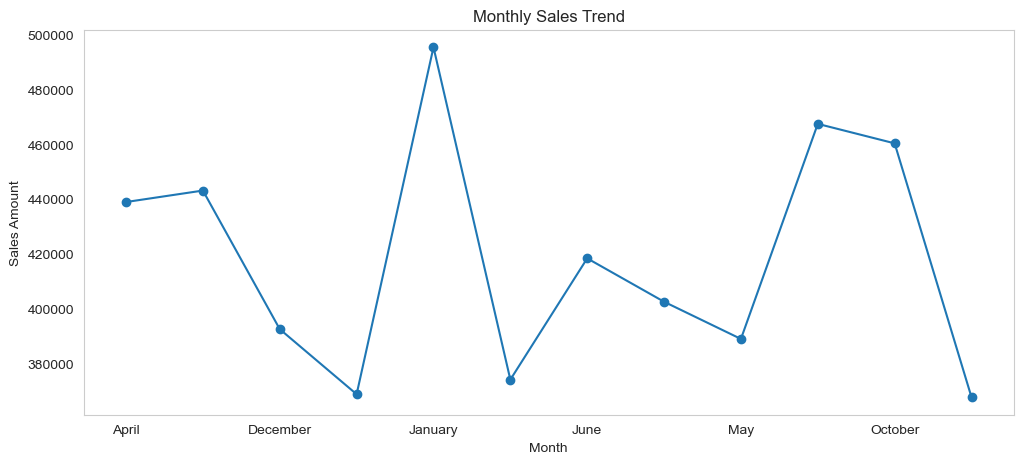

In [ ]:
# ============================================
# VISUALIZATION - MONTHLY SALES TREND
# ============================================

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.grid(False)
plt.savefig(
    "charts/monthly_sales.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
# ============================================
# PAYMENT METHOD ANALYSIS
# ============================================

payment_method = df[
    'Payment_Method'
].value_counts()

print(payment_method)

Payment_Method
Credit Card      345
Bank Transfer    342
Cash             313
Name: count, dtype: int64


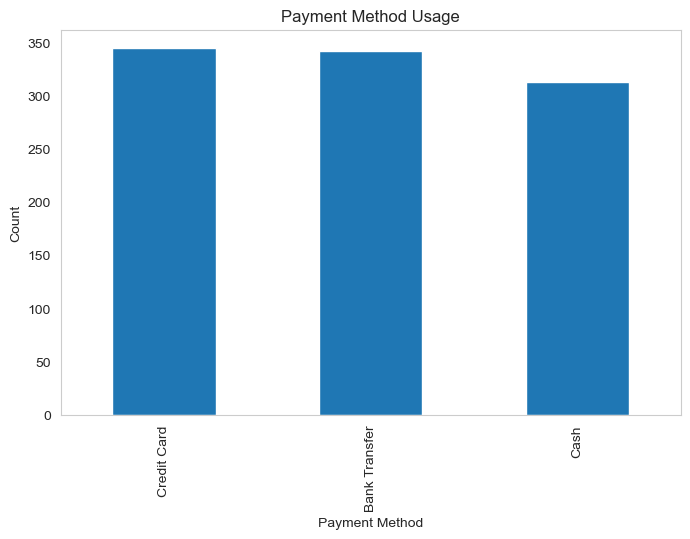

In [ ]:
# ============================================
# VISUALIZATION - PAYMENT METHOD
# ============================================

payment_method.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.grid(False)
plt.savefig(
    "charts/payment_method.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
# ============================================
# SALES CHANNEL ANALYSIS
# ============================================

channel_sales = df.groupby(
    'Sales_Channel'
)['Sales_Amount'].sum()

print(channel_sales)

Sales_Channel
Online    2458833.93
Retail    2560431.30
Name: Sales_Amount, dtype: float64


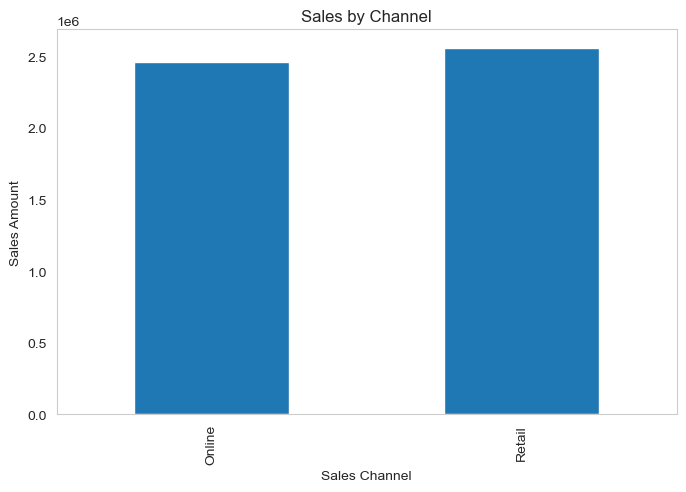

In [ ]:
# ============================================
# VISUALIZATION - SALES CHANNEL
# ============================================

channel_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Sales Amount")
plt.grid(False)
plt.savefig(
    "charts/channel_sales.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

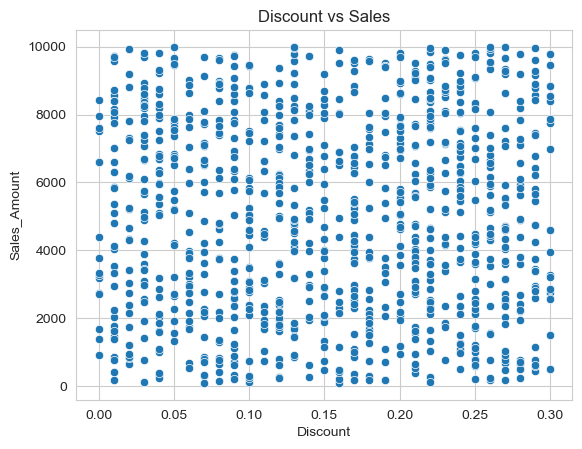

In [ ]:
# ============================================
# DISCOUNT IMPACT ON SALES
# ============================================

sns.scatterplot(
    x='Discount',
    y='Sales_Amount',
    data=df
)

plt.title("Discount vs Sales")

plt.show()

In [ ]:
# ============================================
# CORRELATION MATRIX
# ============================================

correlation = df.corr(numeric_only=True)

correlation

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount,Profit,Profit_Margin,Year,Month
Product_ID,1.000000,0.010221,0.094479,0.013402,0.015116,-0.022097,0.066743,0.031101,0.026981,0.054336
Sales_Amount,0.010221,1.000000,-0.041599,0.009770,0.011812,0.023153,-0.007010,-0.399364,0.027441,-0.006813
Quantity_Sold,0.094479,-0.041599,1.000000,0.053888,0.057296,-0.007806,0.665525,0.232607,0.001208,-0.019017
Unit_Cost,0.013402,0.009770,0.053888,1.000000,0.995056,-0.017741,-0.009190,0.036214,-0.074658,-0.049059
Unit_Price,0.015116,0.011812,0.057296,0.995056,1.000000,-0.017027,0.058301,0.056622,-0.072656,-0.047530
Discount,-0.022097,0.023153,-0.007806,-0.017741,-0.017027,1.000000,-0.019931,-0.035235,0.027867,0.002530
Profit,0.066743,-0.007010,0.665525,-0.009190,0.058301,-0.019931,1.000000,0.318212,0.010412,0.000116
Profit_Margin,0.031101,-0.399364,0.232607,0.036214,0.056622,-0.035235,0.318212,1.000000,-0.012968,0.045008
Year,0.026981,0.027441,0.001208,-0.074658,-0.072656,0.027867,0.010412,-0.012968,1.000000,-0.085325
Month,0.054336,-0.006813,-0.019017,-0.049059,-0.047530,0.002530,0.000116,0.045008,-0.085325,1.000000


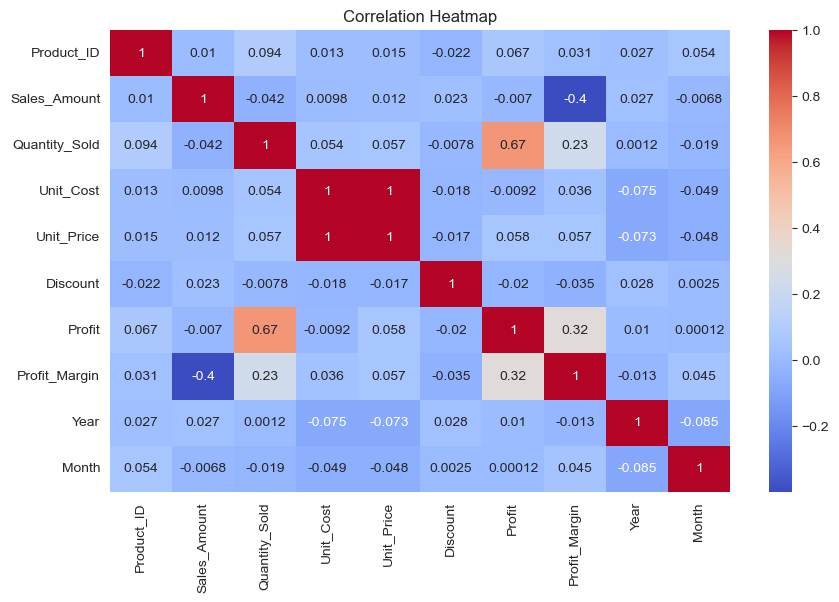

In [ ]:
# ============================================
# HEATMAP
# ============================================

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [75]:
# ============================================
# SALES SUMMARY REPORT
# ============================================

sales_summary = {

    "Total Sales": df['Sales_Amount'].sum(),

    "Total Profit": df['Profit'].sum(),

    "Total Quantity Sold": df['Quantity_Sold'].sum(),

    "Average Sales": df['Sales_Amount'].mean(),

    "Average Profit": df['Profit'].mean(),

    "Maximum Sale": df['Sales_Amount'].max(),

    "Minimum Sale": df['Sales_Amount'].min(),

    "Total Orders": len(df)

}

# Convert dictionary into dataframe
sales_summary_df = pd.DataFrame(
    sales_summary.items(),
    columns=['Metric', 'Value']
)

print(sales_summary_df)

                Metric         Value
0          Total Sales  5.019265e+06
1         Total Profit  6.487847e+06
2  Total Quantity Sold  2.535500e+04
3        Average Sales  5.019265e+03
4       Average Profit  6.487847e+03
5         Maximum Sale  9.989040e+03
6         Minimum Sale  1.001200e+02
7         Total Orders  1.000000e+03


In [76]:
# ============================================
# REGION-WISE SALES REPORT
# ============================================

region_report = df.groupby('Region').agg({

    'Sales_Amount': ['sum', 'mean', 'max'],

    'Profit': ['sum', 'mean'],

    'Quantity_Sold': 'sum'

})

print(region_report)

       Sales_Amount                            Profit               \
                sum         mean      max         sum         mean   
Region                                                               
East     1259792.93  4790.087186  9948.71  1650557.20  6275.882890   
North    1369612.51  5129.634869  9989.04  1661461.20  6222.701124   
South    1154250.86  5107.304690  9961.96  1519736.90  6724.499558   
West     1235608.93  5063.971025  9933.22  1656091.77  6787.261352   

       Quantity_Sold  
                 sum  
Region                
East            6356  
North           6705  
South           5808  
West            6486  


In [77]:
# ============================================
# SALES REPRESENTATIVE REPORT
# ============================================

sales_rep_report = df.groupby('Sales_Rep').agg({

    'Sales_Amount': 'sum',

    'Profit': 'sum',

    'Quantity_Sold': 'sum'

}).sort_values(
    by='Sales_Amount',
    ascending=False
)

print(sales_rep_report)

           Sales_Amount      Profit  Quantity_Sold
Sales_Rep                                         
David        1141737.36  1501749.76           6042
Bob          1080990.63  1170800.24           4977
Eve           970183.99  1449081.90           5287
Alice         965541.77  1294822.01           4832
Charlie       860811.48  1071393.16           4217


In [78]:
# ============================================
# PRODUCT CATEGORY REPORT
# ============================================

category_report = df.groupby(
    'Product_Category'
).agg({

    'Sales_Amount': ['sum', 'mean'],

    'Profit': ['sum', 'mean'],

    'Quantity_Sold': 'sum'

})

print(category_report)

                 Sales_Amount                   Profit               \
                          sum         mean         sum         mean   
Product_Category                                                      
Clothing           1313474.36  4901.023731  1712957.80  6391.633582   
Electronics        1243499.64  5054.876585  1574320.06  6399.675041   
Food               1201773.54  5317.582035  1421108.05  6288.088717   
Furniture          1260517.69  4848.144962  1779461.16  6844.081385   

                 Quantity_Sold  
                           sum  
Product_Category                
Clothing                  6922  
Electronics               6096  
Food                      5608  
Furniture                 6729  


In [79]:
# ============================================
# MONTHLY SALES REPORT
# ============================================

monthly_report = df.groupby(
    'Month_Name'
).agg({

    'Sales_Amount': 'sum',

    'Profit': 'sum',

    'Quantity_Sold': 'sum'

})

print(monthly_report)

            Sales_Amount     Profit  Quantity_Sold
Month_Name                                        
April          438992.61  496006.82           1977
August         443171.28  558417.69           2336
December       392643.58  590397.55           2183
February       368919.36  478053.08           2064
January        495420.37  677764.60           2549
July           374242.88  447678.76           1603
June           418458.34  605992.20           2276
March          402638.77  528631.81           2069
May            389078.76  489472.15           1968
November       467482.90  557812.06           2129
October        460378.78  584679.83           2386
September      367837.60  472940.52           1815


In [80]:
# ============================================
# CUSTOMER TYPE REPORT
# ============================================

customer_report = df.groupby(
    'Customer_Type'
).agg({

    'Sales_Amount': 'sum',

    'Profit': 'sum',

    'Quantity_Sold': 'sum'

})

print(customer_report)

               Sales_Amount      Profit  Quantity_Sold
Customer_Type                                         
New              2506258.30  3431280.76          13184
Returning        2513006.93  3056566.31          12171


In [81]:
# ============================================
# PAYMENT METHOD REPORT
# ============================================

payment_report = df.groupby(
    'Payment_Method'
).agg({

    'Sales_Amount': 'sum',

    'Profit': 'sum'

})

print(payment_report)

                Sales_Amount      Profit
Payment_Method                          
Bank Transfer     1717363.17  2163996.27
Cash              1544338.54  2113293.71
Credit Card       1757563.52  2210557.09


In [85]:
# ============================================
# SALES CHANNEL REPORT
# ============================================

channel_report = df.groupby(
    'Sales_Channel'
).agg({

    'Sales_Amount': 'sum',

    'Profit': 'sum',

    'Quantity_Sold': 'sum'

})

print(channel_report)

               Sales_Amount      Profit  Quantity_Sold
Sales_Channel                                         
Online           2458833.93  3279015.08          12602
Retail           2560431.30  3208831.99          12753


In [86]:
# ============================================
# ADVANCED AGGREGATION
# ============================================

advanced_report = df.groupby(
    'Region'
).agg({

    'Sales_Amount': ['sum', 'mean', 'min', 'max'],

    'Profit': ['sum', 'mean', 'max'],

    'Quantity_Sold': ['sum', 'mean']

})

print(advanced_report)

       Sales_Amount                                    Profit               \
                sum         mean     min      max         sum         mean   
Region                                                                       
East     1259792.93  4790.087186  113.40  9948.71  1650557.20  6275.882890   
North    1369612.51  5129.634869  119.72  9989.04  1661461.20  6222.701124   
South    1154250.86  5107.304690  114.59  9961.96  1519736.90  6724.499558   
West     1235608.93  5063.971025  100.12  9933.22  1656091.77  6787.261352   

                 Quantity_Sold             
             max           sum       mean  
Region                                     
East    22857.04          6356  24.167300  
North   21613.05          6705  25.112360  
South   23441.11          5808  25.699115  
West    21574.52          6486  26.581967  


In [87]:
# ============================================
# PIVOT TABLE REPORT
# ============================================

pivot_report = pd.pivot_table(

    df,

    values='Sales_Amount',

    index='Region',

    columns='Sales_Channel',

    aggfunc='sum',

    fill_value=0

)

print(pivot_report)

Sales_Channel     Online     Retail
Region                             
East           575222.27  684570.66
North          683133.46  686479.05
South          590593.38  563657.48
West           609884.82  625724.11


In [88]:
# ============================================
# TOP 10 PRODUCTS REPORT
# ============================================

top_products = df.groupby(
    'Product_ID'
)['Sales_Amount'].sum().sort_values(
    ascending=False
).head(10)

print(top_products)

Product_ID
1099    101773.87
1092     90615.62
1033     89130.41
1090     88043.25
1086     82269.71
1089     82055.13
1048     81496.82
1001     81017.34
1062     76696.76
1024     75136.67
Name: Sales_Amount, dtype: float64


In [84]:
# ============================================
# CREATE REPORTS FOLDER
# ============================================

os.makedirs("reports", exist_ok=True)

In [89]:
# ============================================
# EXPORT REGION REPORT
# ============================================

region_report.to_csv(
    "reports/region_report.csv"
)

In [90]:
# ============================================
# EXPORT SALES REP REPORT
# ============================================

sales_rep_report.to_csv(
    "reports/sales_rep_report.csv"
)

In [91]:
# ============================================
# EXPORT MONTHLY REPORT
# ============================================

monthly_report.to_csv(
    "reports/monthly_report.csv"
)

In [92]:
# ============================================
# SAVING CLEANED DATASET
# ============================================

df.to_csv(
    "cleaned_sales_data.csv",
    index=False
)